<a href="https://colab.research.google.com/github/nawazgs424-oss/Python-Codes/blob/main/Netflix_project_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wordcloud
# + all import statements


In [ ]:
from google.colab import files
uploaded = files.upload()  # This will show upload dialog


Saving netflix_titles.csv to netflix_titles.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
#Initial data exploration
print("="*60)
print("📋 DATASET OVERVIEW")
print("="*60)

print("\n🔍 Column Names:")
print(list(df.columns))

print("\n📈 Dataset Info:")
df.info()

print("\n👀 First 5 rows:")
display(df.head()) # Using display for better formatting

In [ ]:
from google.colab import files
print("Please upload your Netflix dataset CSV file:")
uploaded = files.upload()

# Get the filename of uploaded file
filename = list(uploaded.keys())[0]
print(f"📁 Uploaded file: {filename}")

# Load the dataset
df = pd.read_csv(filename)
print(f"✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape}")

#Initial data exploration
print("="*60)
print("📋 DATASET OVERVIEW")
print("="*60)

print("\n🔍 Column Names:")
print(list(df.columns))

print("\n📈 Dataset Info:")
df.info()

print("\n👀 First 5 rows:")
display(df.head()) # Using display for better formatting

#Data quality assessment
print("\n" + "="*60)
print("🔍 DATA QUALITY CHECK")
print("="*60)

print("\n❌ Missing Values:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

print("\n📊 Basic Statistics:")
display(df.describe(include='all')) # Using display for better formatting

Please upload your Netflix dataset CSV file:


TypeError: 'NoneType' object is not subscriptable

In [ ]:
#Data quality assessment
print("\n" + "="*60)
print("🔍 DATA QUALITY CHECK")
print("="*60)

print("\n❌ Missing Values:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

print("\n📊 Basic Statistics:")
display(df.describe(include='all')) # Using display for better formatting


🔍 DATA QUALITY CHECK

❌ Missing Values:


NameError: name 'df' is not defined

In [ ]:
#Data cleaning
print("\n" + "="*60)
print("🧹 DATA CLEANING")
print("="*60)

# Create a copy for cleaning
df_clean = df.copy()

# Handle missing values
if 'director' in df_clean.columns:
    df_clean['director'] = df_clean['director'].fillna('Unknown Director')
    print("✅ Filled missing directors")

if 'cast' in df_clean.columns:
    df_clean['cast'] = df_clean['cast'].fillna('Unknown Cast')
    print("✅ Filled missing cast information")

if 'country' in df_clean.columns:
    df_clean['country'] = df_clean['country'].fillna('Unknown Country')
    print("✅ Filled missing country information")

if 'date_added' in df_clean.columns:
    df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')
    print("✅ Converted date_added to datetime")

# Remove duplicates
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
final_rows = len(df_clean)
duplicates_removed = initial_rows - final_rows
print(f"🗑️ Removed {duplicates_removed} duplicate rows")

# Create additional features
if 'date_added' in df_clean.columns:
    df_clean['year_added'] = df_clean['date_added'].dt.year
    df_clean['month_added'] = df_clean['date_added'].dt.month
    print("✅ Created year_added and month_added columns")

# Extract duration information
if 'duration' in df_clean.columns:
    df_clean['duration_mins'] = df_clean['duration'].str.extract('(\d+)').astype(float)
    df_clean['duration_type'] = df_clean['duration'].str.extract('(min|Season)')
    print("✅ Extracted duration information")

print(f"\n✨ Cleaned dataset shape: {df_clean.shape}")
print("\n✅ Data cleaning completed!")


🧹 DATA CLEANING
✅ Filled missing directors
✅ Filled missing cast information
✅ Filled missing country information
✅ Converted date_added to datetime
🗑️ Removed 0 duplicate rows
✅ Created year_added and month_added columns
✅ Extracted duration information

✨ Cleaned dataset shape: (8807, 16)

✅ Data cleaning completed!



📺 CONTENT TYPE ANALYSIS

📊 Content Type Distribution:
  Movie: 6131 (69.6%)
  TV Show: 2676 (30.4%)


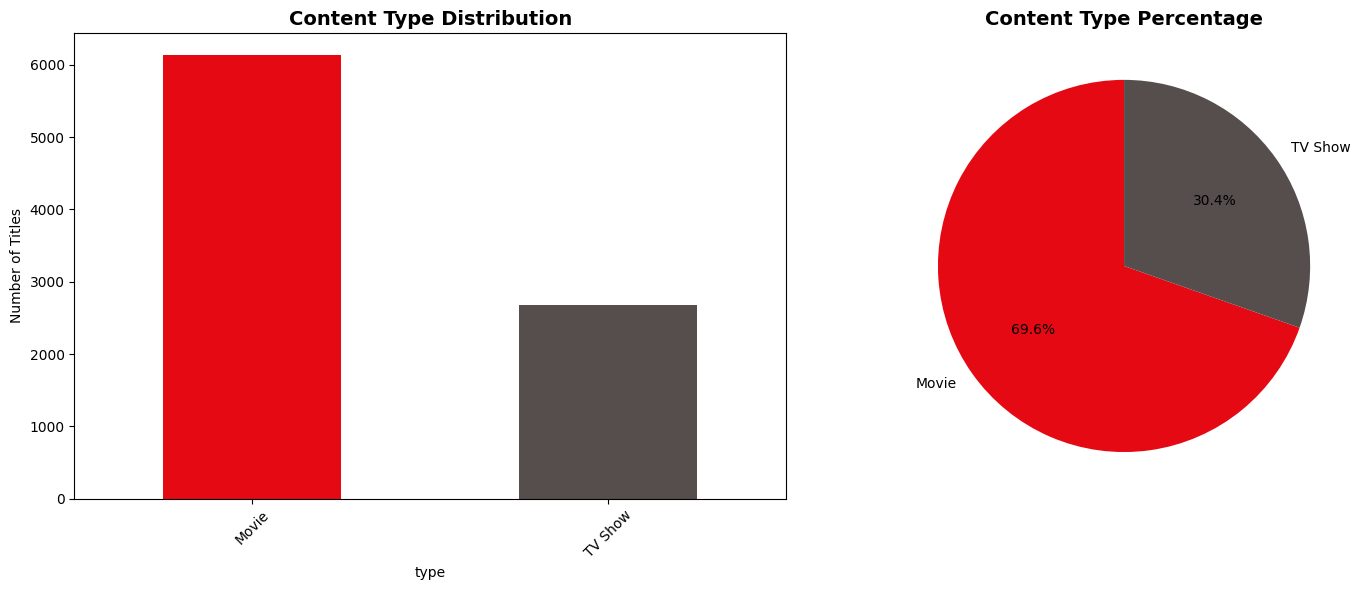

In [ ]:
#Content type analysis
print("\n" + "="*60)
print("📺 CONTENT TYPE ANALYSIS")
print("="*60)

if 'type' in df_clean.columns:
    type_counts = df_clean['type'].value_counts()
    print("\n📊 Content Type Distribution:")
    for content_type, count in type_counts.items():
        percentage = (count/len(df_clean)*100)
        print(f"  {content_type}: {count} ({percentage:.1f}%)")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Bar chart
    type_counts.plot(kind='bar', ax=ax1, color=['#e50914', '#564d4d'])
    ax1.set_title('Content Type Distribution', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Titles')
    ax1.tick_params(axis='x', rotation=45)

    # Pie chart
    ax2.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#e50914', '#564d4d'], startangle=90)
    ax2.set_title('Content Type Percentage', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()


📈 YEARLY TRENDS ANALYSIS

📅 Recent years content addition:
year_added
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


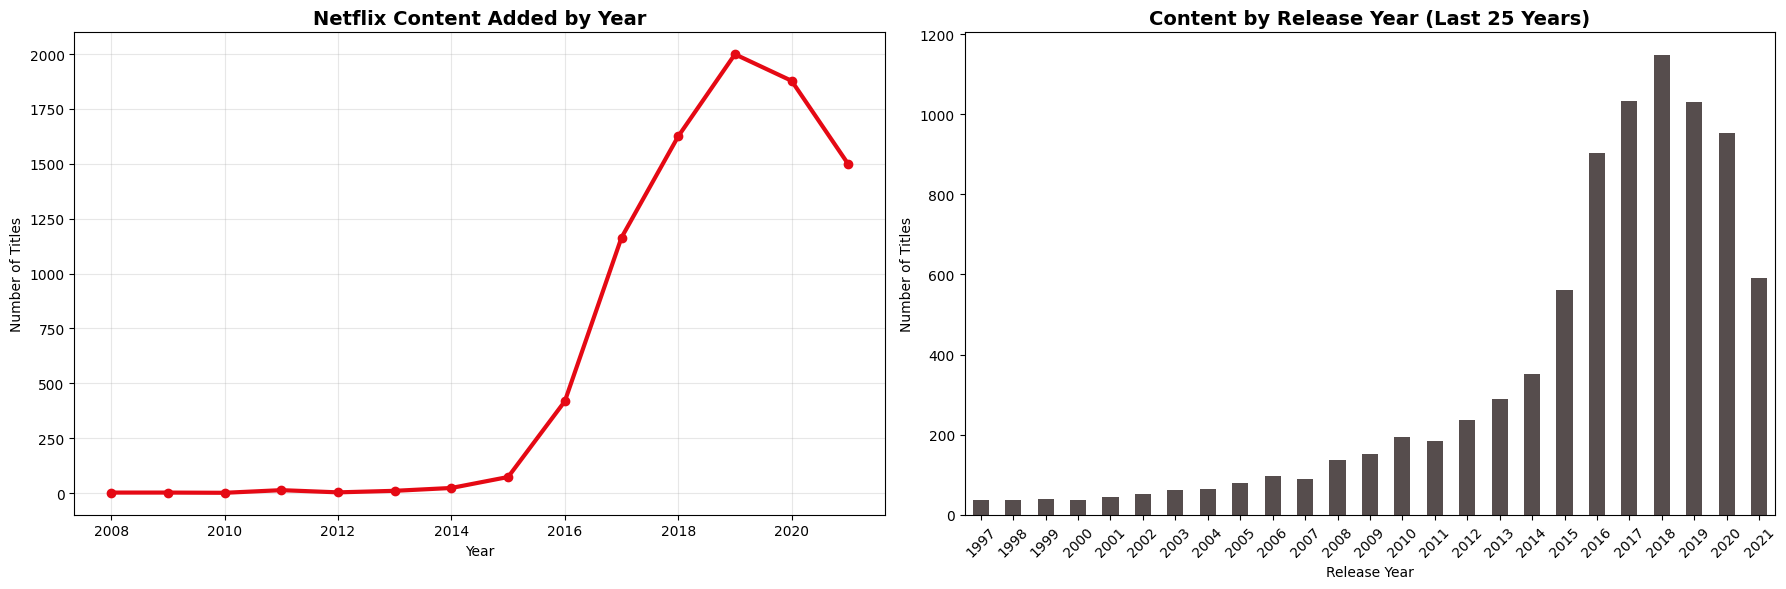

In [ ]:
#Yearly trends analysis
print("\n" + "="*60)
print("📈 YEARLY TRENDS ANALYSIS")
print("="*60)

if 'year_added' in df_clean.columns:
    yearly_content = df_clean['year_added'].value_counts().sort_index()

    print("\n📅 Recent years content addition:")
    print(yearly_content.tail(10))

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Content added by year
    yearly_content.plot(kind='line', ax=ax1, marker='o', color='#e50914', linewidth=3, markersize=6)
    ax1.set_title('Netflix Content Added by Year', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Number of Titles')
    ax1.grid(True, alpha=0.3)

    # Release year analysis
    if 'release_year' in df_clean.columns:
        release_year_counts = df_clean['release_year'].value_counts().sort_index()
        recent_releases = release_year_counts.tail(25)
        recent_releases.plot(kind='bar', ax=ax2, color='#564d4d')
        ax2.set_title('Content by Release Year (Last 25 Years)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Release Year')
        ax2.set_ylabel('Number of Titles')
        ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()



🎭 GENRE ANALYSIS

🏆 Top 15 Genres:
   1. International Movies: 2752
   2. Dramas: 2427
   3. Comedies: 1674
   4. International TV Shows: 1351
   5. Documentaries: 869
   6. Action & Adventure: 859
   7. TV Dramas: 763
   8. Independent Movies: 756
   9. Children & Family Movies: 641
  10. Romantic Movies: 616
  11. TV Comedies: 581
  12. Thrillers: 577
  13. Crime TV Shows: 470
  14. Kids' TV: 451
  15. Docuseries: 395


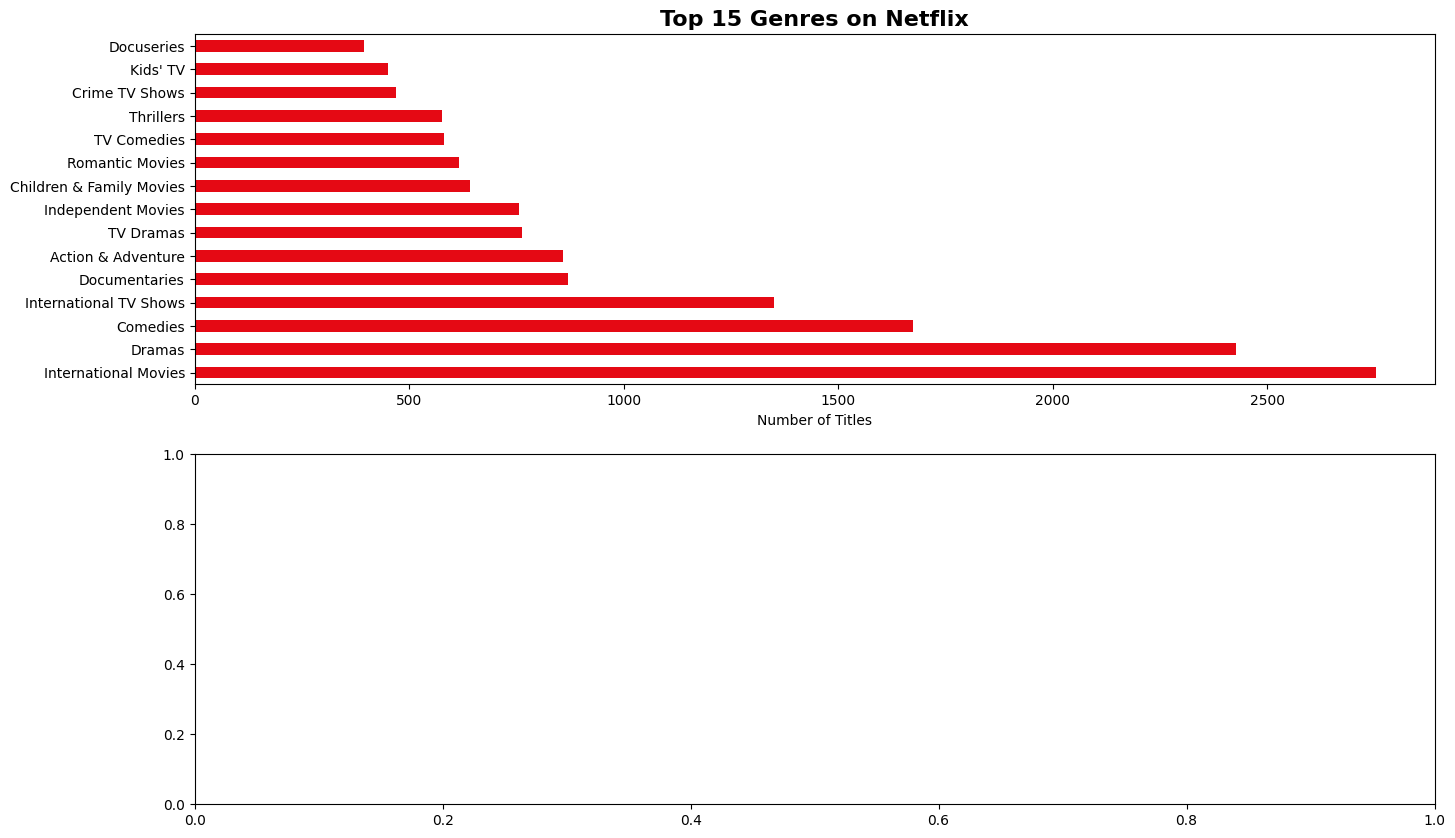

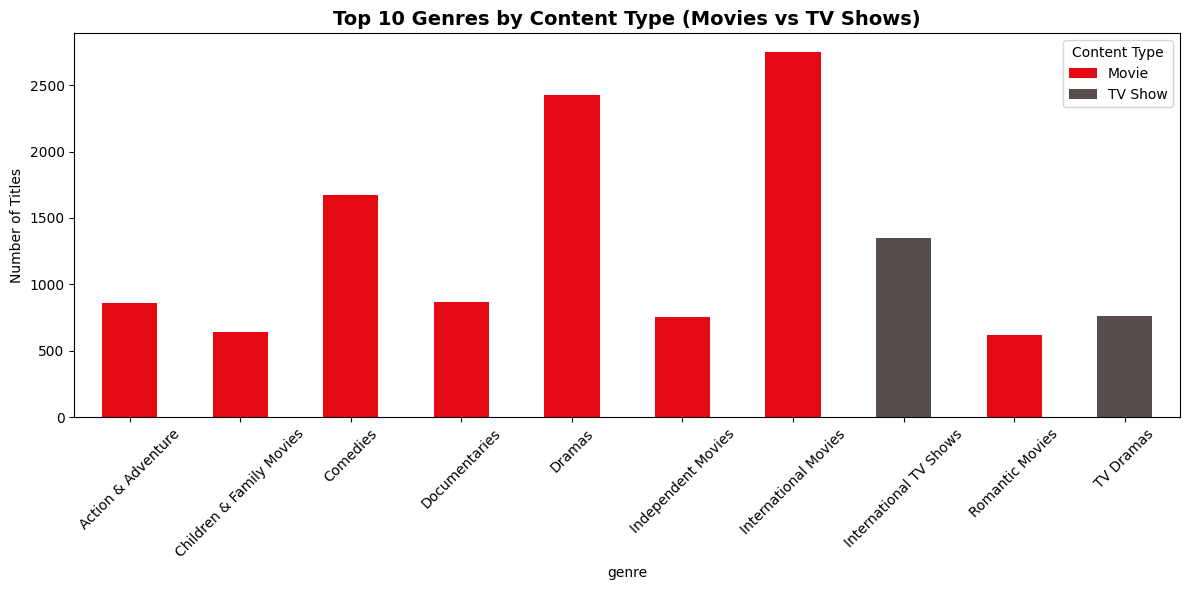

In [ ]:
#top genre analysis
print("\n" + "="*60)
print("🎭 GENRE ANALYSIS")
print("="*60)

if 'listed_in' in df_clean.columns:
    # Extract all genres
    all_genres = []
    for genres in df_clean['listed_in'].dropna():
        all_genres.extend([genre.strip() for genre in genres.split(',')])

    genre_counts = pd.Series(all_genres).value_counts().head(15)

    print("\n🏆 Top 15 Genres:")
    for i, (genre, count) in enumerate(genre_counts.items(), 1):
        print(f"  {i:2d}. {genre}: {count}")

    # Visualization
    plt.figure(figsize=(16, 10))

    # Top genres horizontal bar chart
    plt.subplot(2, 1, 1)
    genre_counts.plot(kind='barh', color='#e50914')
    plt.title('Top 15 Genres on Netflix', fontsize=16, fontweight='bold')
    plt.xlabel('Number of Titles')

    # Genre by content type
    plt.subplot(2, 1, 2)
    if 'type' in df_clean.columns:
        # Create genre-type data
        genre_type_data = []
        for idx, row in df_clean.iterrows():
            if pd.notna(row['listed_in']):
                genres = [g.strip() for g in row['listed_in'].split(',')]
                for genre in genres:
                    genre_type_data.append({'genre': genre, 'type': row['type']})

        genre_type_df = pd.DataFrame(genre_type_data)
        top_genres_list = genre_counts.head(10).index.tolist()
        filtered_data = genre_type_df[genre_type_df['genre'].isin(top_genres_list)]

        genre_type_pivot = filtered_data.pivot_table(index='genre', columns='type',
                                                   aggfunc='size', fill_value=0)
        genre_type_pivot.plot(kind='bar', stacked=True, color=['#e50914', '#564d4d'])
        plt.title('Top 10 Genres by Content Type (Movies vs TV Shows)', fontsize=14, fontweight='bold')
        plt.ylabel('Number of Titles')
        plt.xticks(rotation=45)
        plt.legend(title='Content Type')

    plt.tight_layout()
    plt.show()



🌍 COUNTRY ANALYSIS

🌎 Top 15 Content Producing Countries:
   1. United States: 3690
   2. India: 1046
   3. United Kingdom: 806
   4. Canada: 445
   5. France: 393
   6. Japan: 318
   7. Spain: 232
   8. South Korea: 231
   9. Germany: 226
  10. Mexico: 169
  11. China: 162
  12. Australia: 160
  13. Egypt: 117
  14. Turkey: 113
  15. Hong Kong: 105


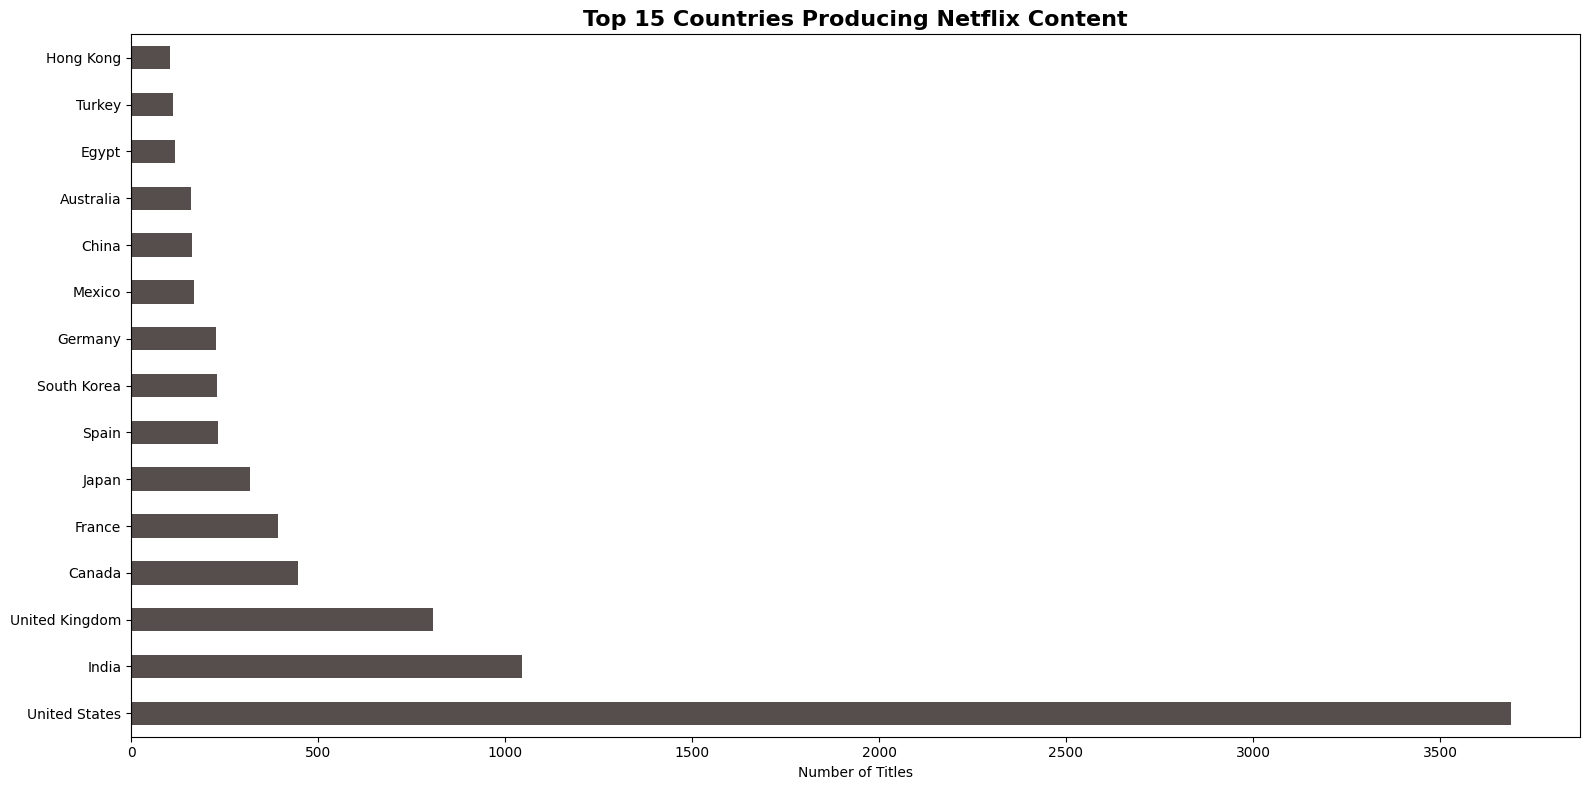

In [ ]:
#Country analysis
print("\n" + "="*60)
print("🌍 COUNTRY ANALYSIS")
print("="*60)

if 'country' in df_clean.columns:
    # Extract all countries
    all_countries = []
    for countries in df_clean['country'].dropna():
        if countries != 'Unknown Country':
            all_countries.extend([country.strip() for country in countries.split(',')])

    country_counts = pd.Series(all_countries).value_counts().head(15)

    print("\n🌎 Top 15 Content Producing Countries:")
    for i, (country, count) in enumerate(country_counts.items(), 1):
        print(f"  {i:2d}. {country}: {count}")

    # Visualization
    plt.figure(figsize=(16, 8))
    country_counts.plot(kind='barh', color='#564d4d')
    plt.title('Top 15 Countries Producing Netflix Content', fontsize=16, fontweight='bold')
    plt.xlabel('Number of Titles')
    plt.tight_layout()
    plt.show()


⭐ RATINGS ANALYSIS

📊 Content Distribution by Rating:
  TV-MA: 3207 (36.4%)
  TV-14: 2160 (24.5%)
  TV-PG: 863 (9.8%)
  R: 799 (9.1%)
  PG-13: 490 (5.6%)
  TV-Y7: 334 (3.8%)
  TV-Y: 307 (3.5%)
  PG: 287 (3.3%)
  TV-G: 220 (2.5%)
  NR: 80 (0.9%)
  G: 41 (0.5%)
  TV-Y7-FV: 6 (0.1%)
  NC-17: 3 (0.0%)
  UR: 3 (0.0%)
  74 min: 1 (0.0%)
  84 min: 1 (0.0%)
  66 min: 1 (0.0%)


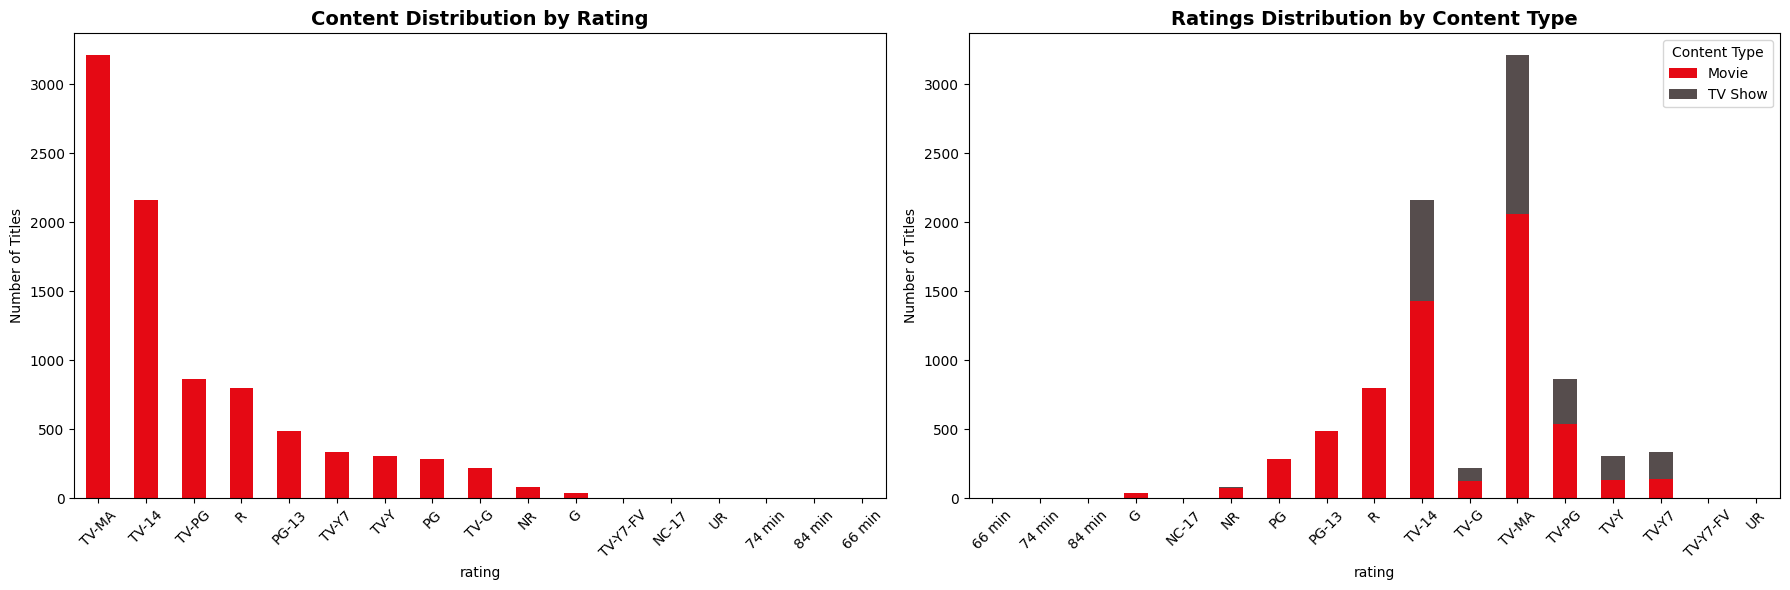

In [ ]:
#rating analysis
print("\n" + "="*60)
print("⭐ RATINGS ANALYSIS")
print("="*60)

if 'rating' in df_clean.columns:
    rating_counts = df_clean['rating'].value_counts()

    print("\n📊 Content Distribution by Rating:")
    for rating, count in rating_counts.items():
        percentage = (count/len(df_clean)*100)
        print(f"  {rating}: {count} ({percentage:.1f}%)")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Overall ratings distribution
    rating_counts.plot(kind='bar', ax=ax1, color='#e50914')
    ax1.set_title('Content Distribution by Rating', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Titles')
    ax1.tick_params(axis='x', rotation=45)

    # Rating by content type
    if 'type' in df_clean.columns:
        rating_type = pd.crosstab(df_clean['rating'], df_clean['type'])
        rating_type.plot(kind='bar', stacked=True, ax=ax2, color=['#e50914', '#564d4d'])
        ax2.set_title('Ratings Distribution by Content Type', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Number of Titles')
        ax2.tick_params(axis='x', rotation=45)
        ax2.legend(title='Content Type')

    plt.tight_layout()
    plt.show()


⏱️ DURATION ANALYSIS

🎬 Movie Duration Statistics:
  Average: 99.6 minutes
  Median: 98.0 minutes
  Shortest: 3 minutes
  Longest: 312 minutes
  Standard Deviation: 28.3 minutes

📺 TV Show Seasons Statistics:
  Average Seasons: 1.8
  Median Seasons: 1.0
  Maximum Seasons: 17


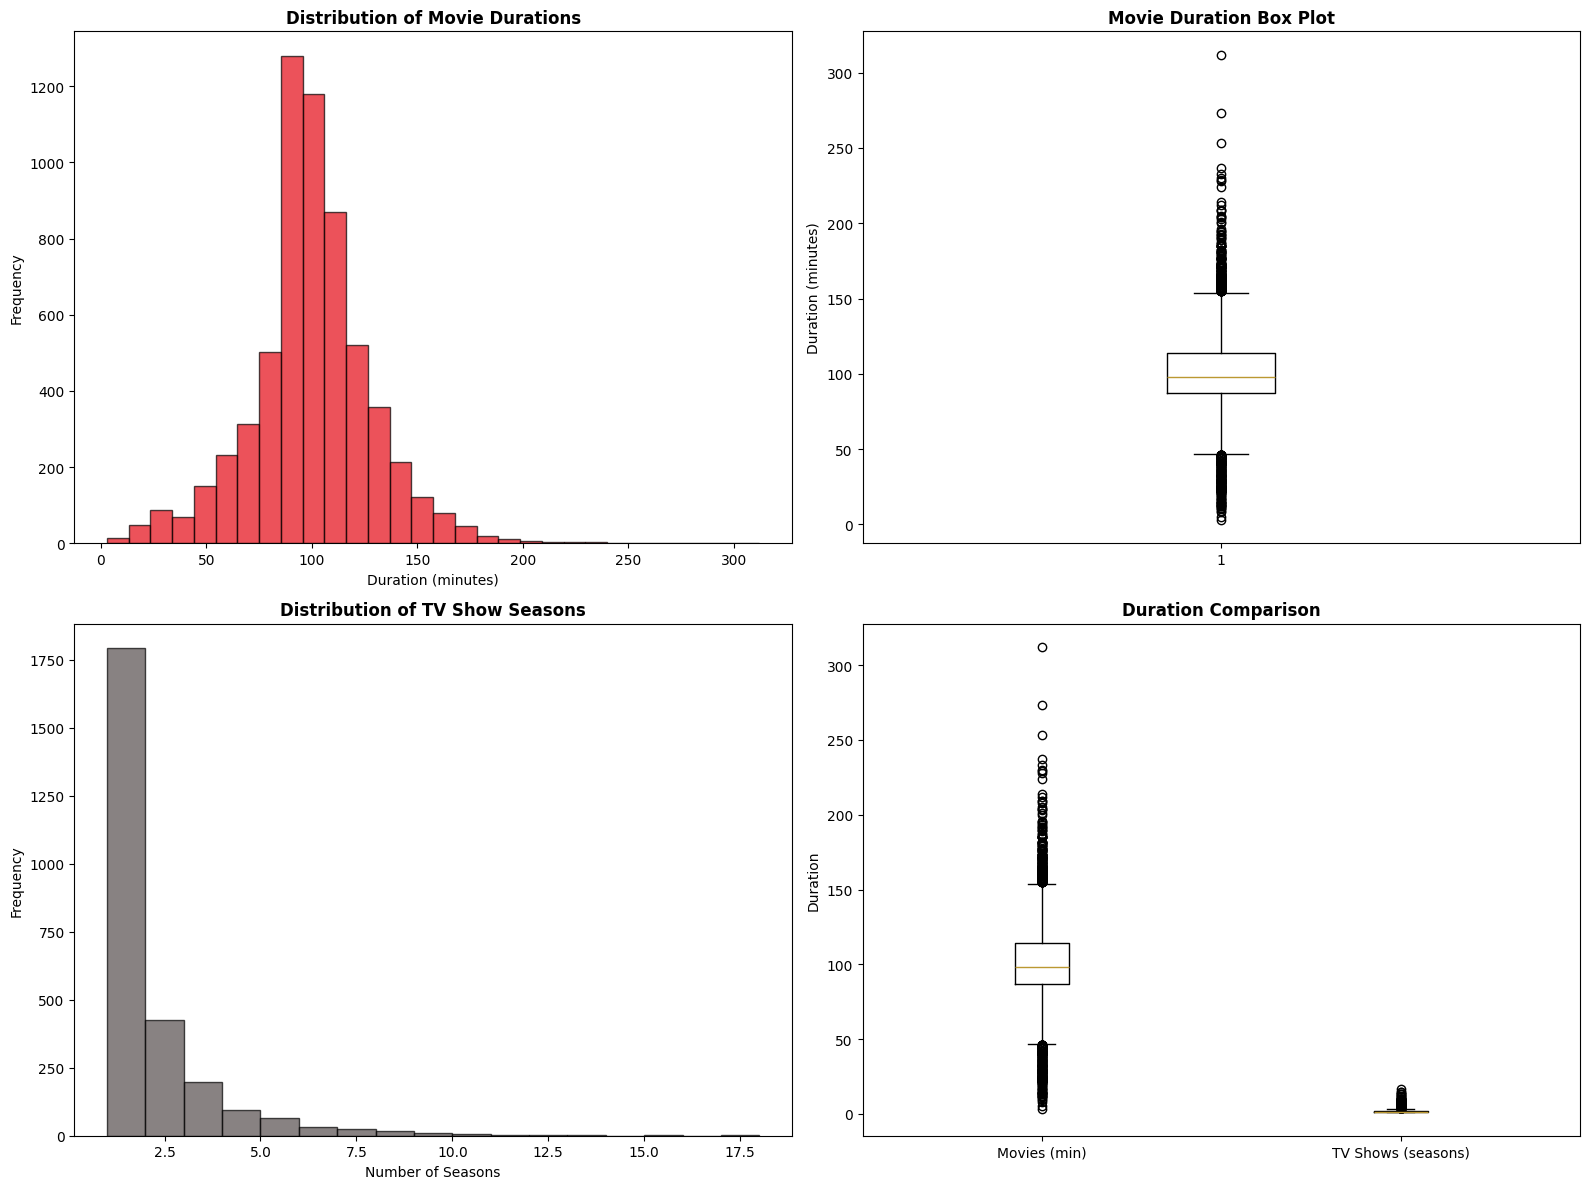

In [ ]:
#Duration analysis
print("\n" + "="*60)
print("⏱️ DURATION ANALYSIS")
print("="*60)

if 'duration_mins' in df_clean.columns and 'type' in df_clean.columns:
    # Movie duration analysis
    movies = df_clean[df_clean['type'] == 'Movie']['duration_mins'].dropna()

    if len(movies) > 0:
        print("\n🎬 Movie Duration Statistics:")
        print(f"  Average: {movies.mean():.1f} minutes")
        print(f"  Median: {movies.median():.1f} minutes")
        print(f"  Shortest: {movies.min():.0f} minutes")
        print(f"  Longest: {movies.max():.0f} minutes")
        print(f"  Standard Deviation: {movies.std():.1f} minutes")

        # TV Show seasons analysis
        tv_shows = df_clean[df_clean['type'] == 'TV Show']['duration_mins'].dropna()
        if len(tv_shows) > 0:
            print("\n📺 TV Show Seasons Statistics:")
            print(f"  Average Seasons: {tv_shows.mean():.1f}")
            print(f"  Median Seasons: {tv_shows.median():.1f}")
            print(f"  Maximum Seasons: {tv_shows.max():.0f}")

        # Visualization
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Movie duration histogram
        axes[0,0].hist(movies, bins=30, color='#e50914', alpha=0.7, edgecolor='black')
        axes[0,0].set_title('Distribution of Movie Durations', fontweight='bold')
        axes[0,0].set_xlabel('Duration (minutes)')
        axes[0,0].set_ylabel('Frequency')

        # Movie duration box plot
        axes[0,1].boxplot(movies)
        axes[0,1].set_title('Movie Duration Box Plot', fontweight='bold')
        axes[0,1].set_ylabel('Duration (minutes)')

        # TV show seasons histogram
        if len(tv_shows) > 0:
            axes[1,0].hist(tv_shows, bins=range(1, int(tv_shows.max())+2),
                          color='#564d4d', alpha=0.7, edgecolor='black')
            axes[1,0].set_title('Distribution of TV Show Seasons', fontweight='bold')
            axes[1,0].set_xlabel('Number of Seasons')
            axes[1,0].set_ylabel('Frequency')

            # Duration comparison
            axes[1,1].boxplot([movies, tv_shows], labels=['Movies (min)', 'TV Shows (seasons)'])
            axes[1,1].set_title('Duration Comparison', fontweight='bold')
            axes[1,1].set_ylabel('Duration')

        plt.tight_layout()
        plt.show()



📅 MONTHLY ADDITION PATTERNS

📊 Content Added by Month:
  Jan: 727
  Feb: 557
  Mar: 734
  Apr: 759
  May: 626
  Jun: 724
  Jul: 819
  Aug: 749
  Sep: 765
  Oct: 755
  Nov: 697
  Dec: 797


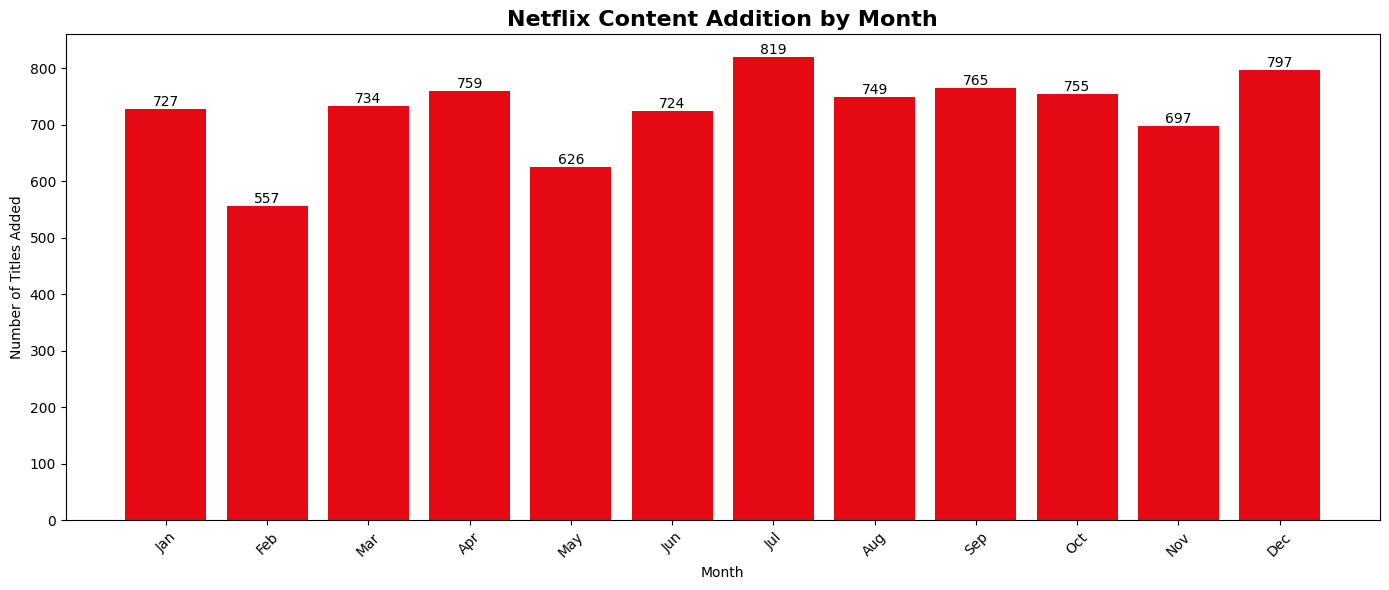

In [ ]:
#Monthly addition patterns
print("\n" + "="*60)
print("📅 MONTHLY ADDITION PATTERNS")
print("="*60)

if 'month_added' in df_clean.columns:
    month_counts = df_clean['month_added'].value_counts().sort_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    print("\n📊 Content Added by Month:")
    valid_months = month_counts.dropna()
    for month_num, count in valid_months.items():
        if pd.notna(month_num):
            month_name = month_names[int(month_num)-1]
            print(f"  {month_name}: {count}")

    # Visualization
    plt.figure(figsize=(14, 6))
    month_labels = [month_names[int(i)-1] for i in valid_months.index]

    bars = plt.bar(month_labels, valid_months.values, color='#e50914')
    plt.title('Netflix Content Addition by Month', fontsize=16, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Number of Titles Added')
    plt.xticks(rotation=45)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()



📝 TEXT ANALYSIS

📖 Analyzing 8807 descriptions...


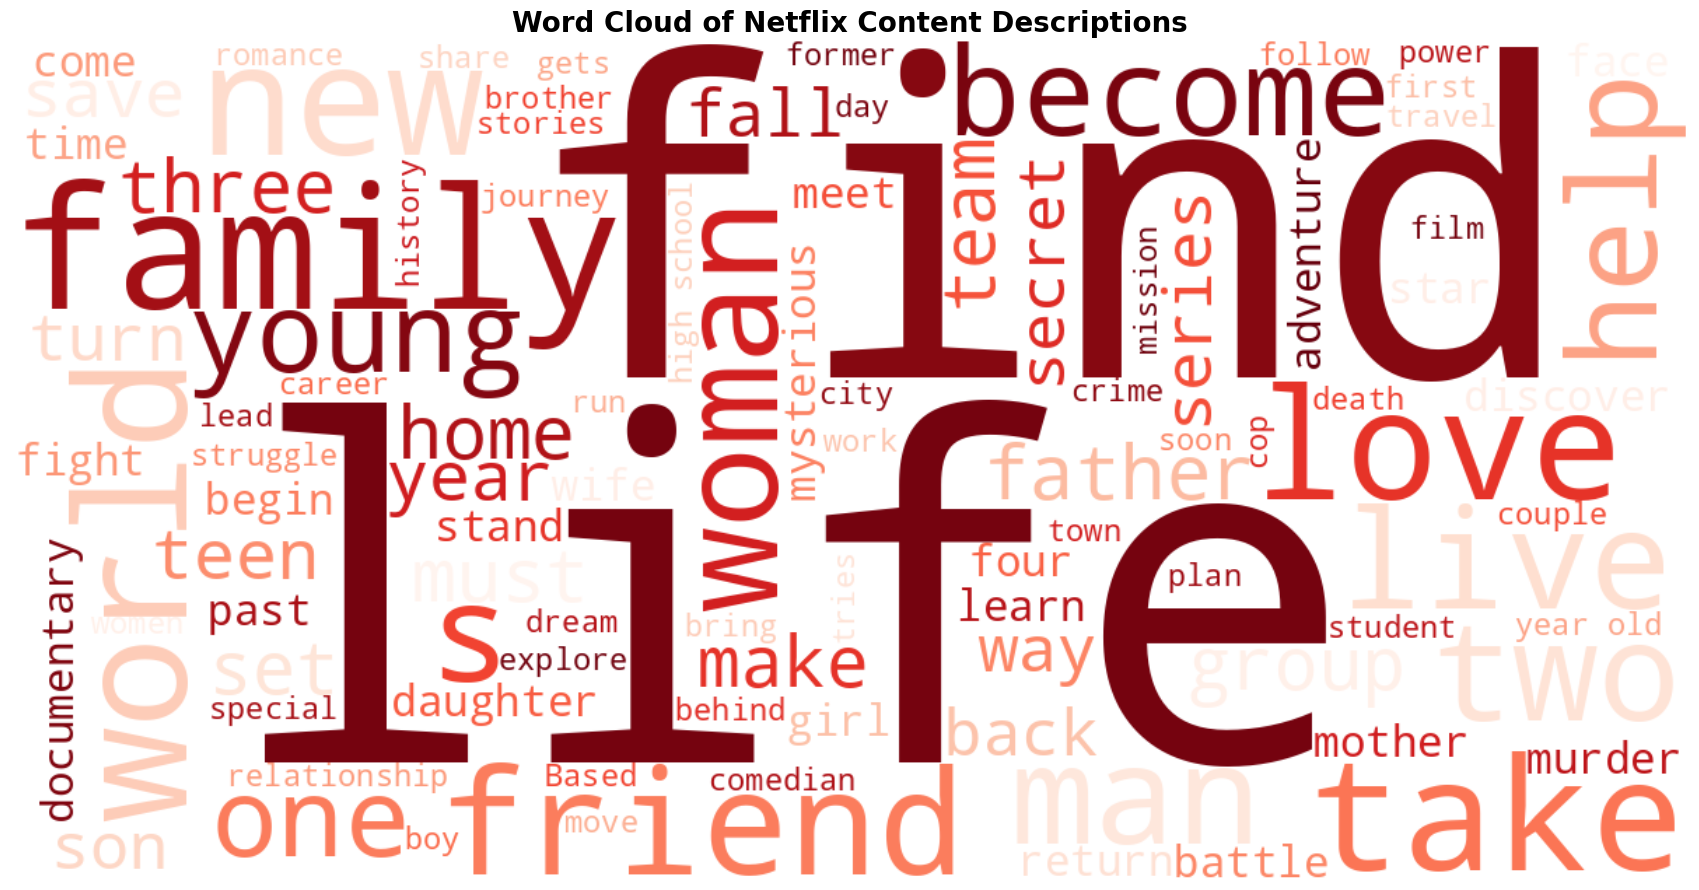

✅ Word cloud generated successfully!


In [ ]:
#Text analysis word cloud
print("\n" + "="*60)
print("📝 TEXT ANALYSIS")
print("="*60)

try:
    from wordcloud import WordCloud

    if 'description' in df_clean.columns:
        # Combine all descriptions
        text = ' '.join(df_clean['description'].dropna().astype(str))

        print(f"\n📖 Analyzing {len(df_clean['description'].dropna())} descriptions...")

        # Create word cloud
        wordcloud = WordCloud(width=1200, height=600,
                            background_color='white',
                            colormap='Reds',
                            max_words=100).generate(text)

        plt.figure(figsize=(18, 9))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('Word Cloud of Netflix Content Descriptions', fontsize=20, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print("✅ Word cloud generated successfully!")
    else:
        print("❌ Description column not found for word cloud analysis.")

except ImportError:
    print("❌ WordCloud library not available. Please install it using: !pip install wordcloud")


In [ ]:
#summary and key insites
print("\n" + "="*60)
print("📊 ANALYSIS SUMMARY")
print("="*60)

print("\n🎯 KEY INSIGHTS:")

# Dataset overview
print(f"\n📋 Dataset Overview:")
print(f"  • Total titles: {len(df_clean):,}")
print(f"  • Duplicates removed: {duplicates_removed}")
print(f"  • Analysis period: {df_clean['year_added'].min():.0f} - {df_clean['year_added'].max():.0f}")

# Content type insights
if 'type' in df_clean.columns:
    type_counts = df_clean['type'].value_counts()
    print(f"\n📺 Content Distribution:")
    for content_type, count in type_counts.items():
        percentage = (count/len(df_clean)*100)
        print(f"  • {content_type}: {count:,} ({percentage:.1f}%)")

# Top insights
if 'listed_in' in df_clean.columns:
    all_genres = []
    for genres in df_clean['listed_in'].dropna():
        all_genres.extend([genre.strip() for genre in genres.split(',')])
    top_genre = pd.Series(all_genres).value_counts().index[0]
    print(f"\n🎭 Most Popular Genre: {top_genre}")

if 'country' in df_clean.columns:
    all_countries = []
    for countries in df_clean['country'].dropna():
        if countries != 'Unknown Country':
            all_countries.extend([country.strip() for country in countries.split(',')])
    if all_countries:
        top_country = pd.Series(all_countries).value_counts().index[0]
        print(f"🌍 Top Content Producer: {top_country}")

if 'rating' in df_clean.columns:
    top_rating = df_clean['rating'].value_counts().index[0]
    print(f"⭐ Most Common Rating: {top_rating}")

if 'year_added' in df_clean.columns:
    peak_year = df_clean['year_added'].value_counts().index[0]
    print(f"📈 Peak Addition Year: {int(peak_year)}")

print("\n✅ Analysis completed successfully!")
print("💾 The cleaned dataset is available in 'df_clean' variable for further analysis.")

# Display final dataset info
print("\n" + "="*60)
print("📋 FINAL DATASET INFO")
print("="*60)
print(f"Shape: {df_clean.shape}")
print("\nColumns:")
for col in df_clean.columns:
    print(f"  • {col}")


📊 ANALYSIS SUMMARY

🎯 KEY INSIGHTS:

📋 Dataset Overview:
  • Total titles: 8,807
  • Duplicates removed: 0
  • Analysis period: 2008 - 2021

📺 Content Distribution:
  • Movie: 6,131 (69.6%)
  • TV Show: 2,676 (30.4%)

🎭 Most Popular Genre: International Movies
🌍 Top Content Producer: United States
⭐ Most Common Rating: TV-MA
📈 Peak Addition Year: 2019

✅ Analysis completed successfully!
💾 The cleaned dataset is available in 'df_clean' variable for further analysis.

📋 FINAL DATASET INFO
Shape: (8807, 16)

Columns:
  • show_id
  • type
  • title
  • director
  • cast
  • country
  • date_added
  • release_year
  • rating
  • duration
  • listed_in
  • description
  • year_added
  • month_added
  • duration_mins
  • duration_type
